In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as rand

Random Vectors:
X vector:  [0.20107946 0.84867102 0.93196894 1.0940716  1.44768698 2.01870786
 2.13370796 2.9085131  3.61540437 4.03516521 4.11315722 5.09170078
 5.6107748  5.64956085 6.94102229 7.55871151 7.78211036 8.27665074
 8.27921144 8.95961982]
Y vector:  [6.51471931e+00 4.04854900e+00 4.13017539e+00 8.99728077e+00
 3.33990770e+00 3.15735708e+00 5.57906475e-01 9.51512990e+00
 4.33053842e-01 9.14311381e+00 7.58527854e+00 1.12551838e+00
 8.53167516e-01 1.68188090e+00 7.36633780e-03 5.15499900e+00
 7.90165939e+00 8.41505541e+00 7.44551384e+00 7.78810482e+00] 

Calculated slope:  0.13875858534826285
Calculated constant:  4.282735429537567
Polynomial Coefficients:  [ 0.05853595 -0.5997125   1.2021703   4.69242347]
Linear Mean Squared Error: 10.4815
Linear R-squared: 0.0143
Polynomial Mean Squared Error: 8.3411
Polynomial R-squared: 0.2156

Model Comparison:
Cubic Polynomial is the better fit based on MSE
Cubic Polynomial is the better fit based on R-squared


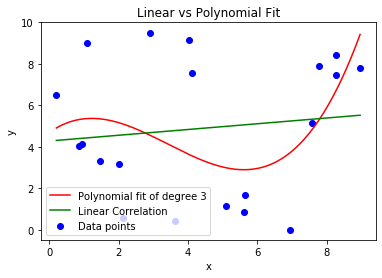

In [2]:
#Challenge A:
def coded_least_square(X,Y):
    n=len(X)
    sum_x= np.sum(X)
    sum_y= np.sum(Y)
    sum_x2=np.sum(X**2)
    sum_xy=np.sum(X*Y)
    
    m=(n*sum_xy-sum_x*sum_y)/(n*sum_x2-(sum_x)**2)
    c=(sum_y-m*sum_x)/n
    return m,c
#Random Vectors
Xrand= np.random.uniform(0,10,20)
Yrand= np.random.uniform(0,10,20)
idx= np.argsort(Xrand) #sort vector
Xrand= Xrand[idx]
Yrand= Yrand[idx]
print("Random Vectors:")
print("X vector: ", Xrand)
print("Y vector: ",Yrand, "\n")


#LINEAR
m_calculated,c_calculated=coded_least_square(Xrand,Yrand)
print("Calculated slope: ", m_calculated)
print("Calculated constant: ", c_calculated)
Y_linear = m_calculated*Xrand + c_calculated

#POLY
coefficients= np.polyfit(Xrand,Yrand,3)
polynomial= np.poly1d(coefficients)
print("Polynomial Coefficients: ", coefficients)
y_pred=polynomial(Xrand)

#MSE and R-Square for Linear
mse_linear= np.mean((Yrand-Y_linear)**2)
print(f'Linear Mean Squared Error: {mse_linear:.4f}')
ss_total = np.sum((Yrand - np.mean(Yrand))**2)
ss_res = np.sum((Yrand - Y_linear)**2)
r_squared_linear = 1 - (ss_res / ss_total)
print(f'Linear R-squared: {r_squared_linear:.4f}')
      
# MSE and R-Square for Polynomial
# Mean Squared Error (MSE)
mse_poly = np.mean((Yrand - y_pred)**2)
print(f'Polynomial Mean Squared Error: {mse_poly:.4f}')
# R-squared value
ss_total_poly = np.sum((Yrand - np.mean(Yrand))**2)
ss_res_poly = np.sum((Yrand - y_pred)**2)
r_squared_poly = 1 - (ss_res_poly / ss_total_poly)
print(f'Polynomial R-squared: {r_squared_poly:.4f}')

#comparing
print("\nModel Comparison:")
if mse_linear < mse_poly:
    print("Linear Least Squares is the better fit based on MSE")
else:
    print("Cubic Polynomial is the better fit based on MSE")
if r_squared_linear > r_squared_poly:
    print("Linear Least Squares is the better fit based on R-squared")
else:
    print("Cubic Polynomial is the better fit based on R-squared")

#Plotting the results
x_plot = np.linspace(min(Xrand), max(Xrand), 200)
y_poly_plot = polynomial(x_plot)
y_linear_plot = m_calculated*x_plot + c_calculated
plt.scatter(Xrand, Yrand, color='blue', label='Data points') # Original data points
plt.plot(x_plot, y_poly_plot, color='red', label=f'Polynomial fit of degree {3}')
plt.plot(x_plot,y_linear_plot,color='green',label="Linear Correlation")
# Fitted curve
plt.title('Linear vs Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Linear Mean Squared Error: 10.4815
Linear R-squared: 0.0143
Degree 3
MSE: 8.3411
Polynomial R-squared: 0.2156

Degree 4
MSE: 8.1723
Polynomial R-squared: 0.2315

Degree 5
MSE: 6.6617
Polynomial R-squared: 0.3735

Degree 6
MSE: 5.5291
Polynomial R-squared: 0.4800

Degree 7
MSE: 5.2806
Polynomial R-squared: 0.5034

Degree 8
MSE: 5.1941
Polynomial R-squared: 0.5115

Degree 9
MSE: 5.1755
Polynomial R-squared: 0.5133

Degree 10
MSE: 4.6725
Polynomial R-squared: 0.5606

Degree 2
MSE: 8.9471
Polynomial R-squared: 0.1586

Degree 1
MSE: 10.4815
Polynomial R-squared: 0.0143



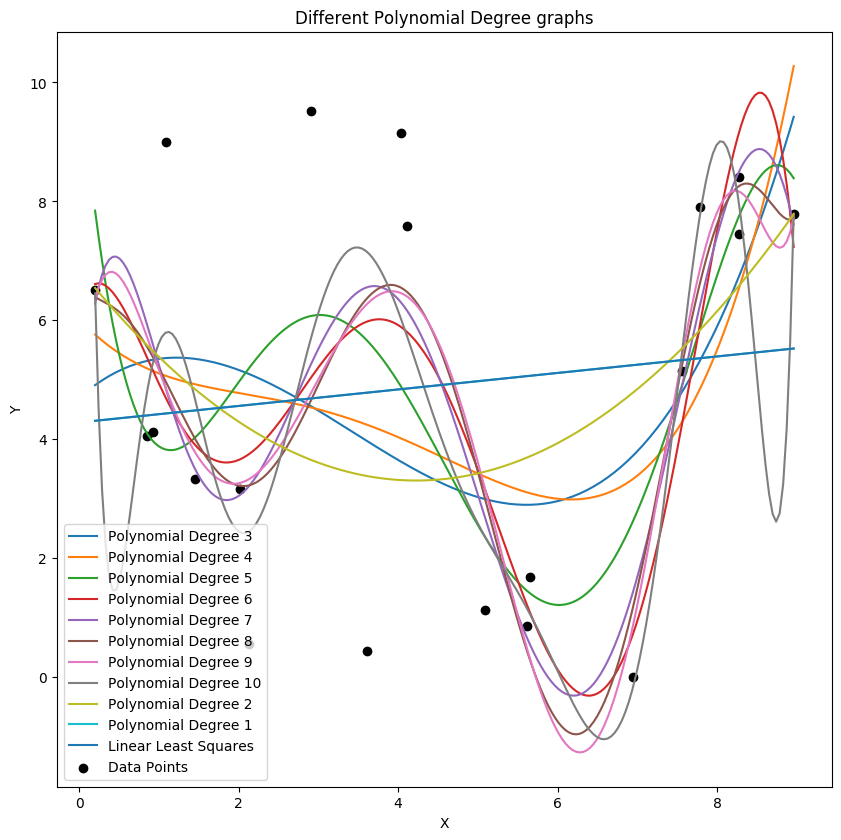

In [3]:
#Challenge B
plt.figure(figsize=(10,10), dpi=100)
#Random Vectors from previous challenge
#LINEAR
m_calculated,c_calculated=coded_least_square(Xrand,Yrand)
Y_linear = m_calculated*Xrand + c_calculated

#MSE and R-Square for Linear
mse_linear= np.mean((Yrand-Y_linear)**2)
print(f'Linear Mean Squared Error: {mse_linear:.4f}')
ss_total = np.sum((Yrand - np.mean(Yrand))**2)
ss_res = np.sum((Yrand - Y_linear)**2)
r_squared_linear = 1 - (ss_res / ss_total)
print(f'Linear R-squared: {r_squared_linear:.4f}')
      
# MSE and R-Square for Polynomial
#POLY
for degree in range(3,11):
    coefficients= np.polyfit(Xrand,Yrand,degree)
    polynomial= np.poly1d(coefficients)
    y_pred=polynomial(Xrand)
    
    mse_poly = np.mean((Yrand - y_pred)**2)
    
    ss_total_poly = np.sum((Yrand - np.mean(Yrand))**2)
    ss_res_poly = np.sum((Yrand - y_pred)**2)
    r_squared_poly = 1 - (ss_res_poly / ss_total_poly)
    print (f"Degree {degree}")
    print (f"MSE: {mse_poly:.4f}")
    print (f"Polynomial R-squared: {r_squared_poly:.4f}\n")
    x_plot = np.linspace(min(Xrand), max(Xrand), 200)
    plt.plot(x_plot, polynomial(x_plot), label=f"Polynomial Degree {degree}")
for degree in range (2,0,-1):
    coefficients= np.polyfit(Xrand,Yrand,degree)
    polynomial= np.poly1d(coefficients)
    y_pred=polynomial(Xrand)
    
    mse_poly = np.mean((Yrand - y_pred)**2)
    
    ss_total_poly = np.sum((Yrand - np.mean(Yrand))**2)
    ss_res_poly = np.sum((Yrand - y_pred)**2)
    r_squared_poly = 1 - (ss_res_poly / ss_total_poly)
    print (f"Degree {degree}")
    print (f"MSE: {mse_poly:.4f}")
    print (f"Polynomial R-squared: {r_squared_poly:.4f}\n")
    x_plot = np.linspace(min(Xrand), max(Xrand), 200)
    plt.plot(x_plot, polynomial(x_plot), label=f"Polynomial Degree {degree}")

plt.plot(x_plot, y_linear_plot, label="Linear Least Squares")
plt.scatter(Xrand, Yrand, label="Data Points", color="black")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Different Polynomial Degree graphs")
plt.legend()
plt.show()

Vandermonde Polynomial Fit Results:

Degree: 1
Coefficients: [4.28273543 0.13875859]
MSE: 10.481477923906507
R^2: 0.014305256959925905

Degree: 2
Coefficients: [ 6.87610229 -1.68967514  0.19991829]
MSE: 8.947071023614367
R^2: 0.15860330598340522

Degree: 3
Coefficients: [ 4.69242347  1.2021703  -0.5997125   0.05853595]
MSE: 8.341119468141361
R^2: 0.21558794756762256

Degree: 4
Coefficients: [ 6.02862479 -1.46467476  0.69475579 -0.16158335  0.01207558]
MSE: 8.172302081142968
R^2: 0.2314638013456991

Degree: 5
Coefficients: [ 10.32766597 -14.36691006  10.65057313  -3.08673751   0.37250551
  -0.01573626]
MSE: 6.661742343074815
R^2: 0.3735192255588934

Degree: 6
Coefficients: [ 6.20224353e+00  3.72961436e+00 -9.57960881e+00  5.92766732e+00
 -1.49971520e+00  1.65890594e-01 -6.65077822e-03]
MSE: 5.529144072429984
R^2: 0.4800305562563111

Degree: 7
Coefficients: [ 3.95464922e+00  1.66275184e+01 -2.84265692e+01  1.73965735e+01
 -4.96780595e+00  7.15749222e-01 -5.03831215e-02  1.37557900e-03]
M

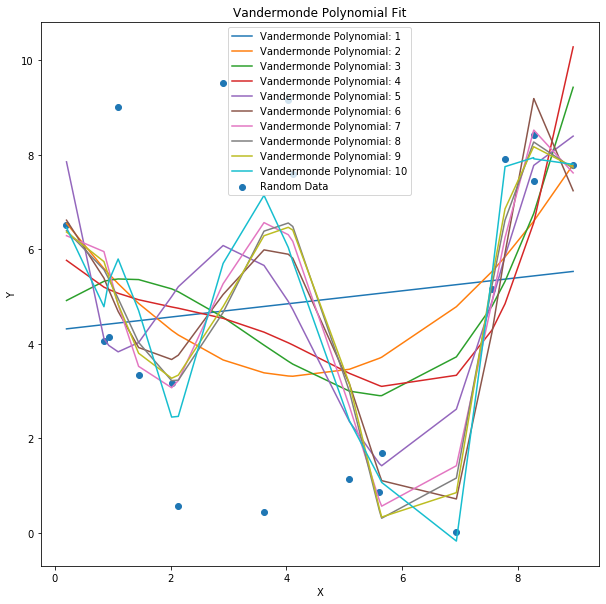

In [4]:
#Challenge C
plt.figure(figsize=(10,10))
plt.scatter(Xrand, Yrand, label="Random Data")

def create_vandermonde(x, degree):
    return np.vander(x, N=degree+1, increasing=True)
# coefficients
def vandermonde_fit(x, y, degree):
    V = create_vandermonde(x, degree)
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)
    return coefficients
# y values
def predict(x, coefficients):
    degree = len(coefficients) - 1
    V = create_vandermonde(x, degree)
    return np.dot(V, coefficients)
# Evaluate model
def evaluate(y, y_pred):
    mse = np.mean((y - y_pred)**2)
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r2 = 1 - (ss_res / ss_total)
    return mse, r2

# Polynomial degrees
print("Vandermonde Polynomial Fit Results:\n")
for degree in range(1,11):
    coeffs = vandermonde_fit(Xrand, Yrand, degree)
    y_pred = predict(Xrand, coeffs)
    mse, r2 = evaluate(Yrand, y_pred)
    print("Degree:", degree)
    print("Coefficients:", coeffs)
    print("MSE:", mse)
    print("R^2:", r2)
    print()
    plt.plot(Xrand, y_pred, label=f"Vandermonde Polynomial: {degree}")
#Plot
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Vandermonde Polynomial Fit")
plt.legend()
plt.show()